# 01 | Exploratory Data Analysis

**Author:** Nguyen (Sue) Huynh  
**Last Updated:** June 2026

---

**Objectives**

This notebook explores the Criteo Uplift Dataset to inform modeling decisions 
for the subsequent uplift modeling pipeline. Specifically, we aim to:

1. Assess covariate balance between treatment and control groups
2. Verify the positivity assumption across the feature space
3. Quantify class imbalance in the outcome variable
4. Examine pairwise feature correlations and potential confounding structure
5. Visualize preliminary evidence of treatment effect heterogeneity 
   via quartile-based uplift analysis

---

**Contents**

1. Setup and Data Loading
2. Covariate Balance Analysis
3. Positivity Check
4. Class Imbalance
5. Pairwise Feature Correlations
6. Quartile-Based Uplift Analysis

## 1. Setup and Data Loading

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from config.config import Config
from src.data.loader import UpliftDataset, DataLoader

c:\Users\nguye\uplift-modeling\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [41]:
cfg = Config()
loader = DataLoader(cfg)
loader.load(subsample_size=cfg.subsample_size)
df = loader.data

In [42]:
df.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,21.265452,10.059654,8.214383,4.679882,10.280525,4.115453,-12.641800,4.833815,3.971858,13.190056,5.300375,-0.168679,0,0,0,0
1,25.744310,10.059654,8.214383,4.679882,10.280525,4.115453,-3.282109,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
2,12.616365,10.059654,8.813527,4.679882,10.280525,4.115453,0.294443,4.833815,3.906514,13.190056,5.300375,-0.168679,1,0,0,0
3,12.616365,10.059654,8.876285,4.679882,10.280525,4.115453,0.294443,4.833815,3.895862,13.190056,5.300375,-0.168679,1,0,0,0
4,12.616365,10.059654,9.007057,4.679882,10.280525,4.115453,0.294443,4.833815,3.890052,13.190056,5.300375,-0.168679,1,0,0,0


In [44]:
X = df[cfg.feature_cols]
y = df[cfg.outcome_col]
treatment = df["treatment"]

## 2. Covariate Balance Analysis

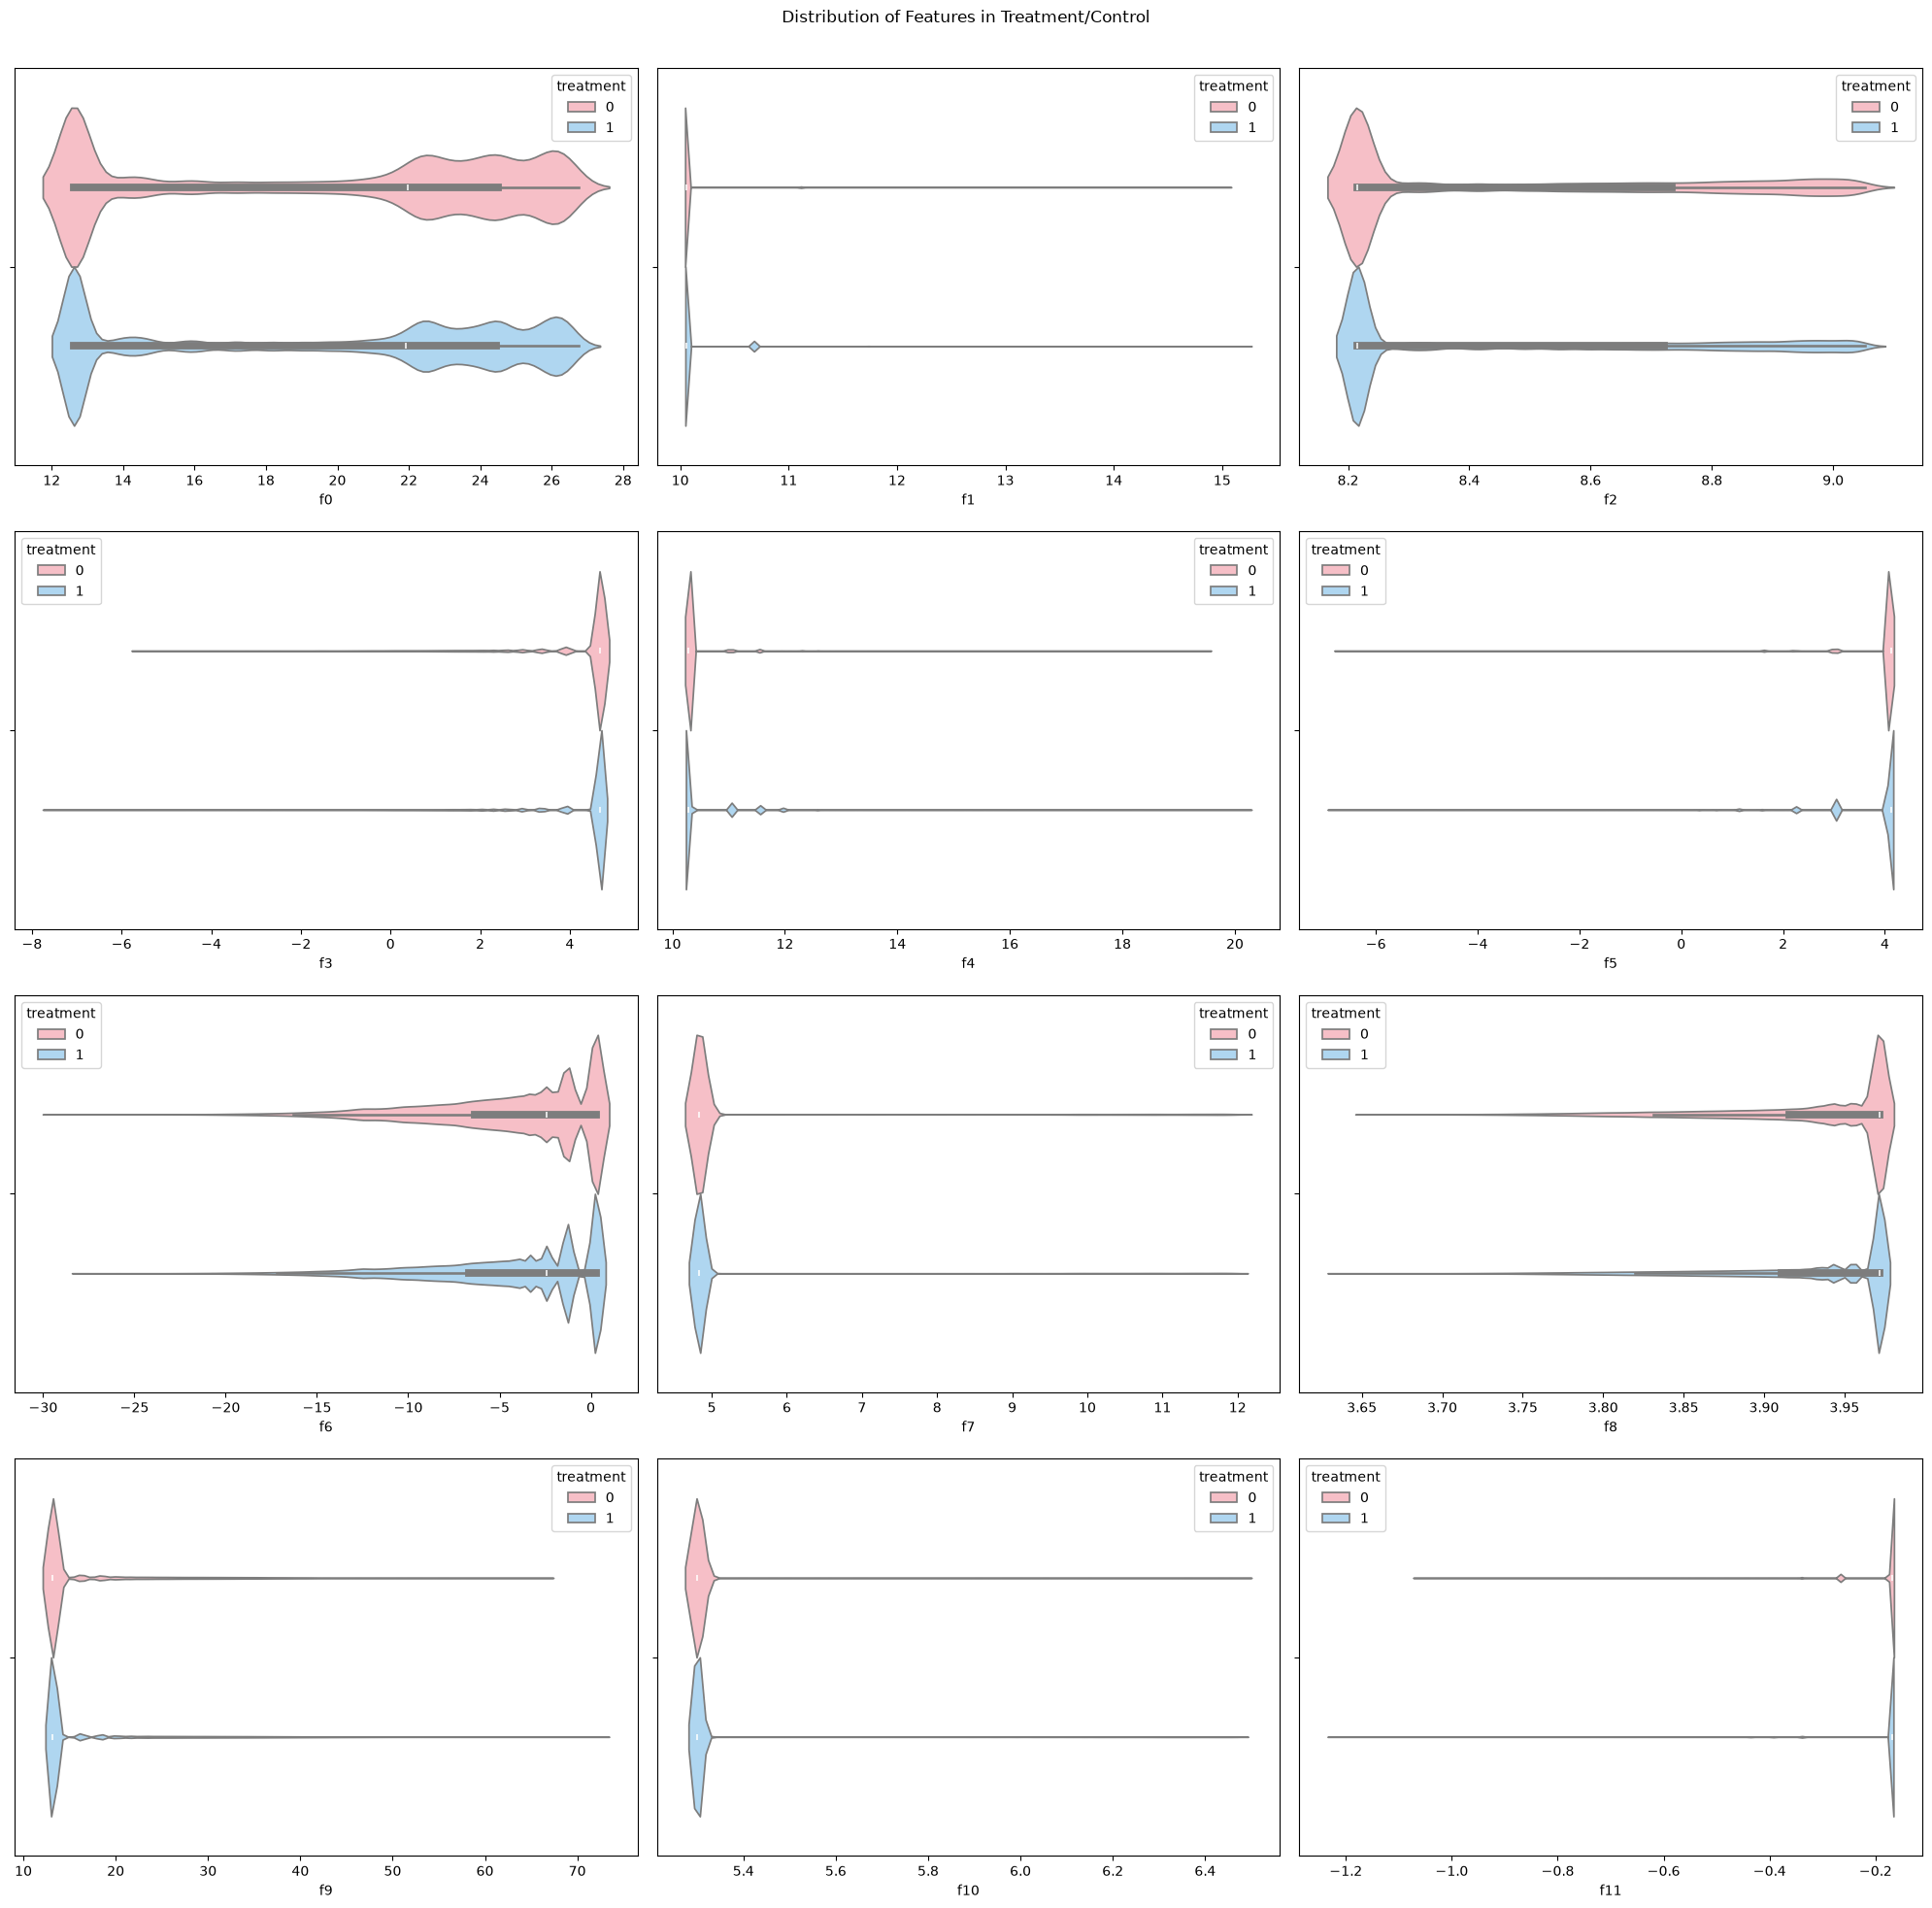

In [22]:
fig, axes = plt.subplots(4, 3, figsize = (20,20))
groups = {1: "#A4D8FB", # treatment
         0: "#FFB6C1" # control
        }
for i, column in enumerate(X.columns):
    plt.subplots_adjust(top = 0.85)
    ax = sns.violinplot(data=df,
                x = df[f'f{i}'],
                hue = df['treatment'],
                palette = groups,
                ax = axes[(i) // 3, (i) % 3])
    ax.set_ylabel('')
fig.tight_layout(h_pad = 2)
plt.suptitle('Distribution of Features in Treatment/Control')
fig.subplots_adjust(top = 0.95)

### 2.1 Treatment vs. Control Feature Distributions
To assess randomization quality, we examined the distribution of all 12 features across treatment and control groups using violin plots. Across nearly all features, treatment and control groups exhibit near-identical density distributions, supporting the unconfoundedness assumption: **treatment assignment is independent of observed covariates**. This is a critical prerequisite for valid causal inference and suggests the Criteo experiment was well-randomized.

### 2.2 Feature Distribution Characteristics
Features exhibit three distinct distributional patterns. 
1. First, features f1, f3, f4, f5, f7, f9, f10, and f11 are highly concentrated and unimodal with long tails, suggesting heavy skewness. These features may benefit from log-transformation prior to modeling, provided non-negativity conditions are satisfied. 
2. Second, f2 exhibits a clear bimodal distribution with a dominant left peak around 8.2 and a secondary right peak.
3. Third, f0, f6 and f8 show multimodal patterns with extended whiskers. The presence of multimodality in several features hints at distinct user subpopulations, which motivates the use of uplift modeling to capture heterogeneous treatment effects across these segments.

### 2.3 Next Steps
- Check non-negativity of skewed features before applying log-transformation; shift features where necessary to satisfy this condition.
- Despite slight multimodal pattern in f8, we will also apply the above process for it because all of its modes are highly skewed to the right.
- Set scale_pos_weight to the ratio of negative to positive examples, penalizing misclassification of the minority class during training.

## 3. Positivity Check

To verify the positivity assumption, we estimated propensity scores using an XGBoost 
classifier trained to predict treatment assignment from observed features. Under perfect 
randomization, features should not predict treatment, yielding propensity scores near 
the empirical treatment rate and a ROC-AUC close to 0.5.

> **Positivity Assumption** requires that for every combination of baseline covariates (confounders), a subject has a non-zero probability of receiving any possible value of the continuous treatment or exposure.

In [45]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

X_train, X_test, t_train, t_test = train_test_split(X, treatment, test_size=cfg.test_size, random_state=cfg.random_state)

model = XGBClassifier(eval_metric='auc', **cfg.xgb_params)
model.fit(X_train, t_train)

t_test_probs = model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(t_test, t_test_probs)
print(f"ROC AUC Score: {auc_score:.4f}")

ROC AUC Score: 0.5107


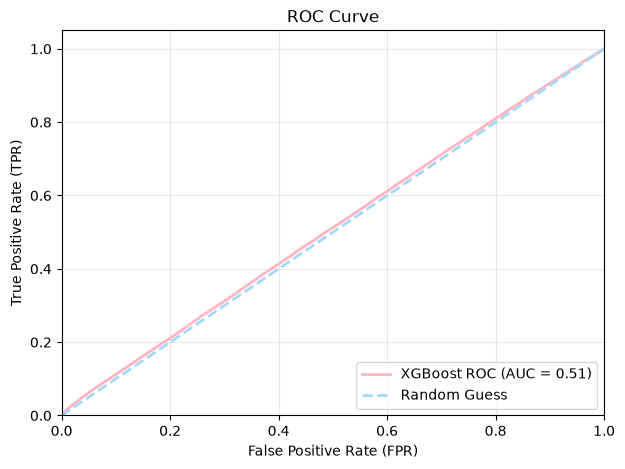

In [57]:
# Compute metrics for the curve
fpr, tpr, thresholds = roc_curve(t_test, t_test_probs)

# Plot the ROC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#FFB6C1', lw=2, label=f'XGBoost ROC (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='#A4D8FB', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

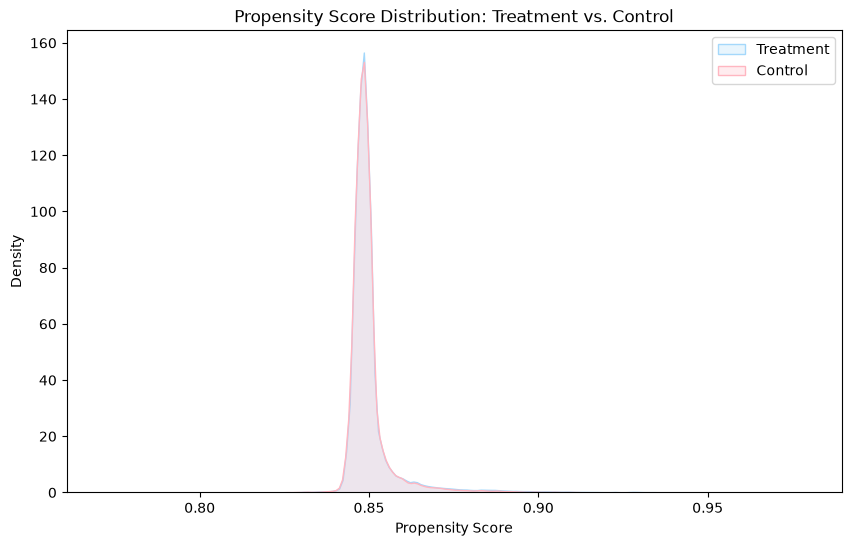

In [64]:
# Separate scores
t_test_array = t_test.to_numpy()
treated_scores = t_test_probs[t_test_array == 1]
control_scores = t_test_probs[t_test_array == 0]

# Plotting
plt.figure(figsize=(10, 6))
sns.kdeplot(treated_scores, label='Treatment', color='#A4D8FB', fill=True)
sns.kdeplot(control_scores, label='Control', color='#FFB6C1', fill=True)

plt.title('Propensity Score Distribution: Treatment vs. Control')
plt.xlabel('Propensity Score')
plt.ylabel('Density')
plt.legend()
plt.show()

**Results:**
- ROC-AUC Score: 0.5107, confirming that treatment assignment is nearly 
  unpredictable from observed covariates
- Propensity score distributions for treatment and control groups are tightly 
  concentrated around 0.85 with near-perfect overlap

The propensity score of ~0.85 reflects the empirical treatment rate in the dataset 
(approximately 85% of units received treatment). The near-identical distributions 
between groups confirm that the Criteo experiment was well-randomized and that the 
positivity assumption holds across the feature space.

## 4. Class Imbalance

We examined class imbalance across three binary variables: treatment assignment, 
visit rate, and conversion rate.

C:\Users\nguye\AppData\Local\Temp\ipykernel_39676\2135899866.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df,
C:\Users\nguye\AppData\Local\Temp\ipykernel_39676\2135899866.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df,
C:\Users\nguye\AppData\Local\Temp\ipykernel_39676\2135899866.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df,


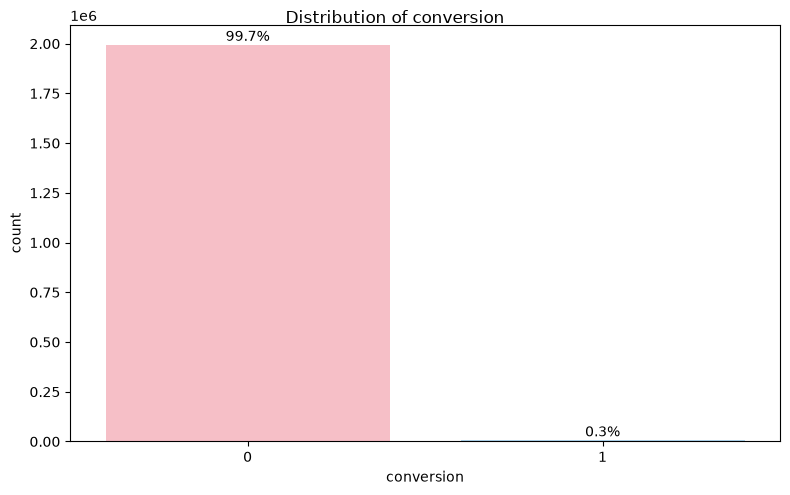

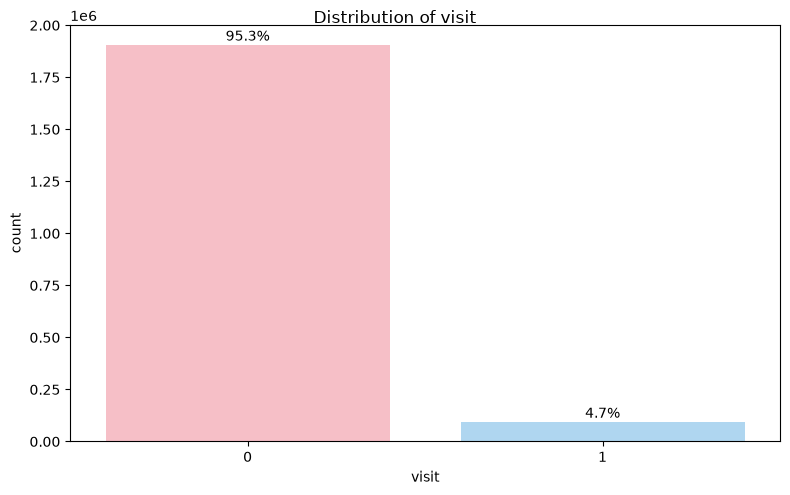

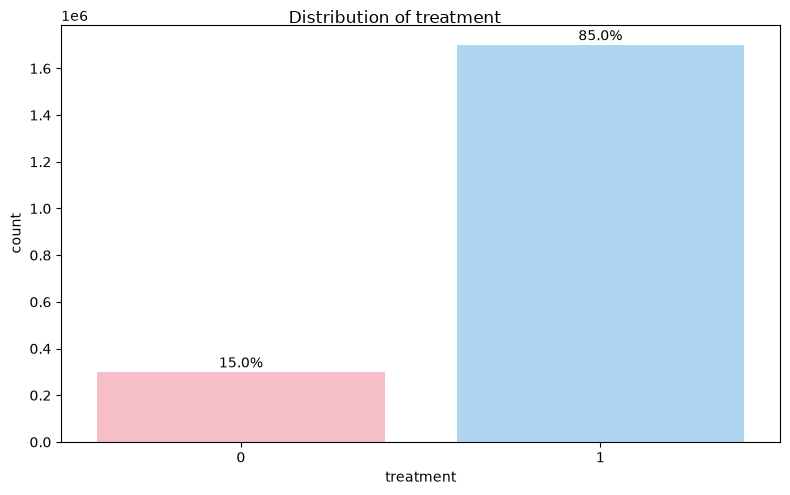

In [78]:
classes = ["conversion", "visit", "treatment"]
for clz in classes:
    fig, ax = plt.subplots(figsize=(8, 5))
    groups = {'1': "#A4D8FB", 
            '0': "#FFB6C1"
            }

    ax = sns.countplot(data=df,
                x=clz,
                palette=groups)

    total = float(len(df))

    for p in ax.patches:
        height = p.get_height()
        percentage = (height / total) * 100
        
        ax.text(
            p.get_x() + p.get_width() / 2., 
            height + len(df)/100,                    
            f'{percentage:.1f}%',           
            ha="center"                   
        )

    fig.tight_layout(h_pad = 2)
    plt.suptitle(f'Distribution of {clz}')
    fig.subplots_adjust(top = 0.95)

**Treatment/Control Split:**  
Approximately 85% of units received treatment and 15% were assigned to control, 
reflecting a deliberate imbalance in the Criteo experimental design rather than 
a data quality issue.

**Outcome Variables:**  
Both outcome variables exhibit severe class imbalance. The visit rate is positive 
for approximately 4.7% of units, while the conversion rate is positive for only 
0.3% — a 300:1 negative-to-positive ratio. This level of imbalance poses a 
significant risk of models learning to predict the majority class exclusively.

**Next Steps:**  
To address outcome imbalance in our XGBoost base learners, we set `scale_pos_weight` 
to the ratio of negative to positive examples for each outcome variable separately.

## 5. Pairwise Feature Correlations

We examined pairwise Pearson correlations across all 12 features using a heatmap, 
flagging pairs with |correlation| >= 0.5 as meaningfully correlated.

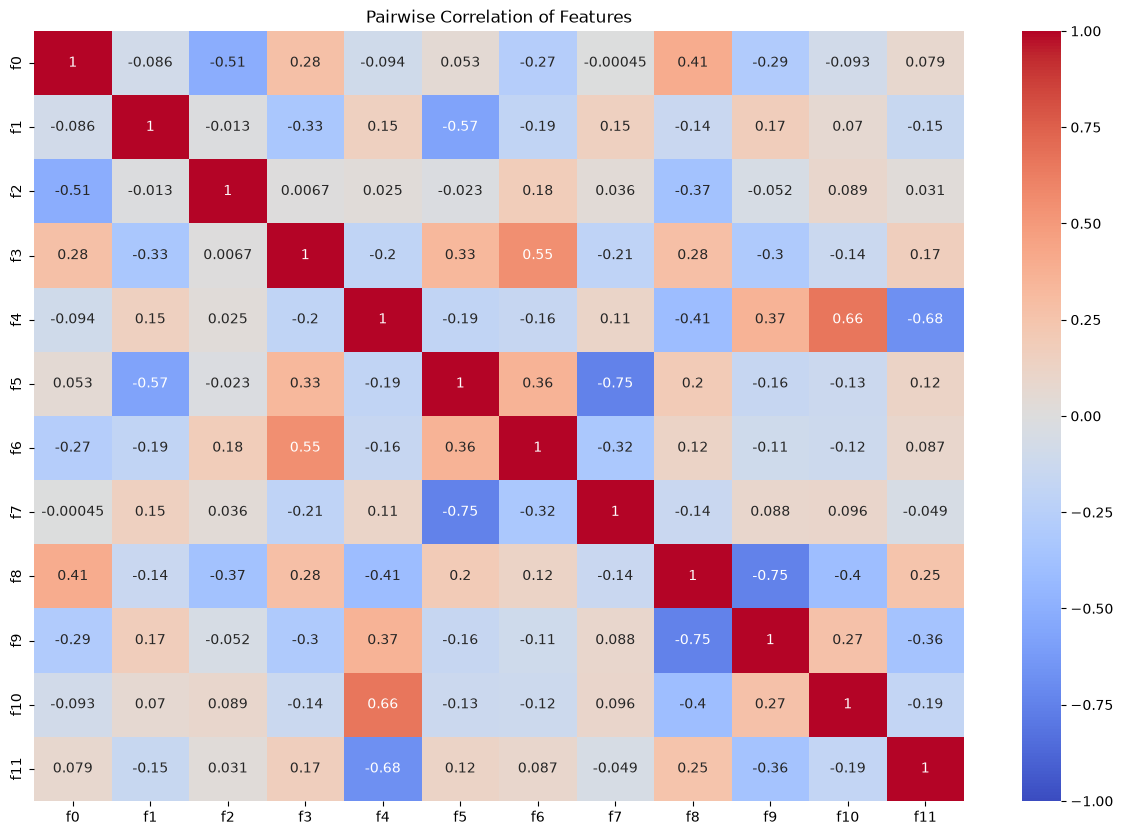

In [83]:
corr_matrix = X.corr()

fig, ax = plt.subplots(figsize=(15, 10))
ax = sns.heatmap(corr_matrix, vmin=-1, vmax=1, annot=True, cmap='coolwarm')
ax.set_title("Pairwise Correlation of Features")
plt.show()

**Results:**
| Feature Pair | Correlation | Direction |
|---|---|---|
| f0, f2 | -0.51 | Negative |
| f1, f5 | -0.57 | Negative |
| f3, f6 | 0.55 | Positive |
| f4, f10 | 0.66 | Positive |
| f4, f11 | -0.68 | Negative |
| f5, f7 | -0.75 | Negative |
| f8, f9 | -0.75 | Negative |

**Key Findings:**

**Multicollinearity:** Several feature pairs exhibit strong correlations, particularly 
`f5-f7` and `f8-f9` at -0.75. While XGBoost is more robust to multicollinearity than 
linear models due to its tree-based feature selection, correlated features may cause 
unstable feature importance scores as importance is split arbitrarily between them.

**Potential Common Cause Structure:** `f4` is strongly correlated with both `f10` 
(+0.66) and `f11` (-0.68), yet `f10` and `f11` are nearly uncorrelated (-0.19). 
This pattern suggests `f4` may be a common cause of both features.

## 6. Quartile-Based Uplift Analysis

To examine treatment effect heterogeneity prior to modeling, we divided each feature 
into quartiles (Q1-Q4) and computed the raw uplift, defined as the difference in 
mean outcome between treatment and control groups, within each quartile. This analysis 
was conducted separately for both outcome variables: **visits** and **conversions**.

In [152]:
X_quartile = X.copy()
for col in X.columns:
    X_quartile[col] = pd.qcut(X_quartile[col].rank(method='first'), q=4, labels=[1, 2, 3, 4])

df_quartile = pd.merge(X_quartile, df[["treatment", "visit", "conversion"]], left_index=True, right_index=True)

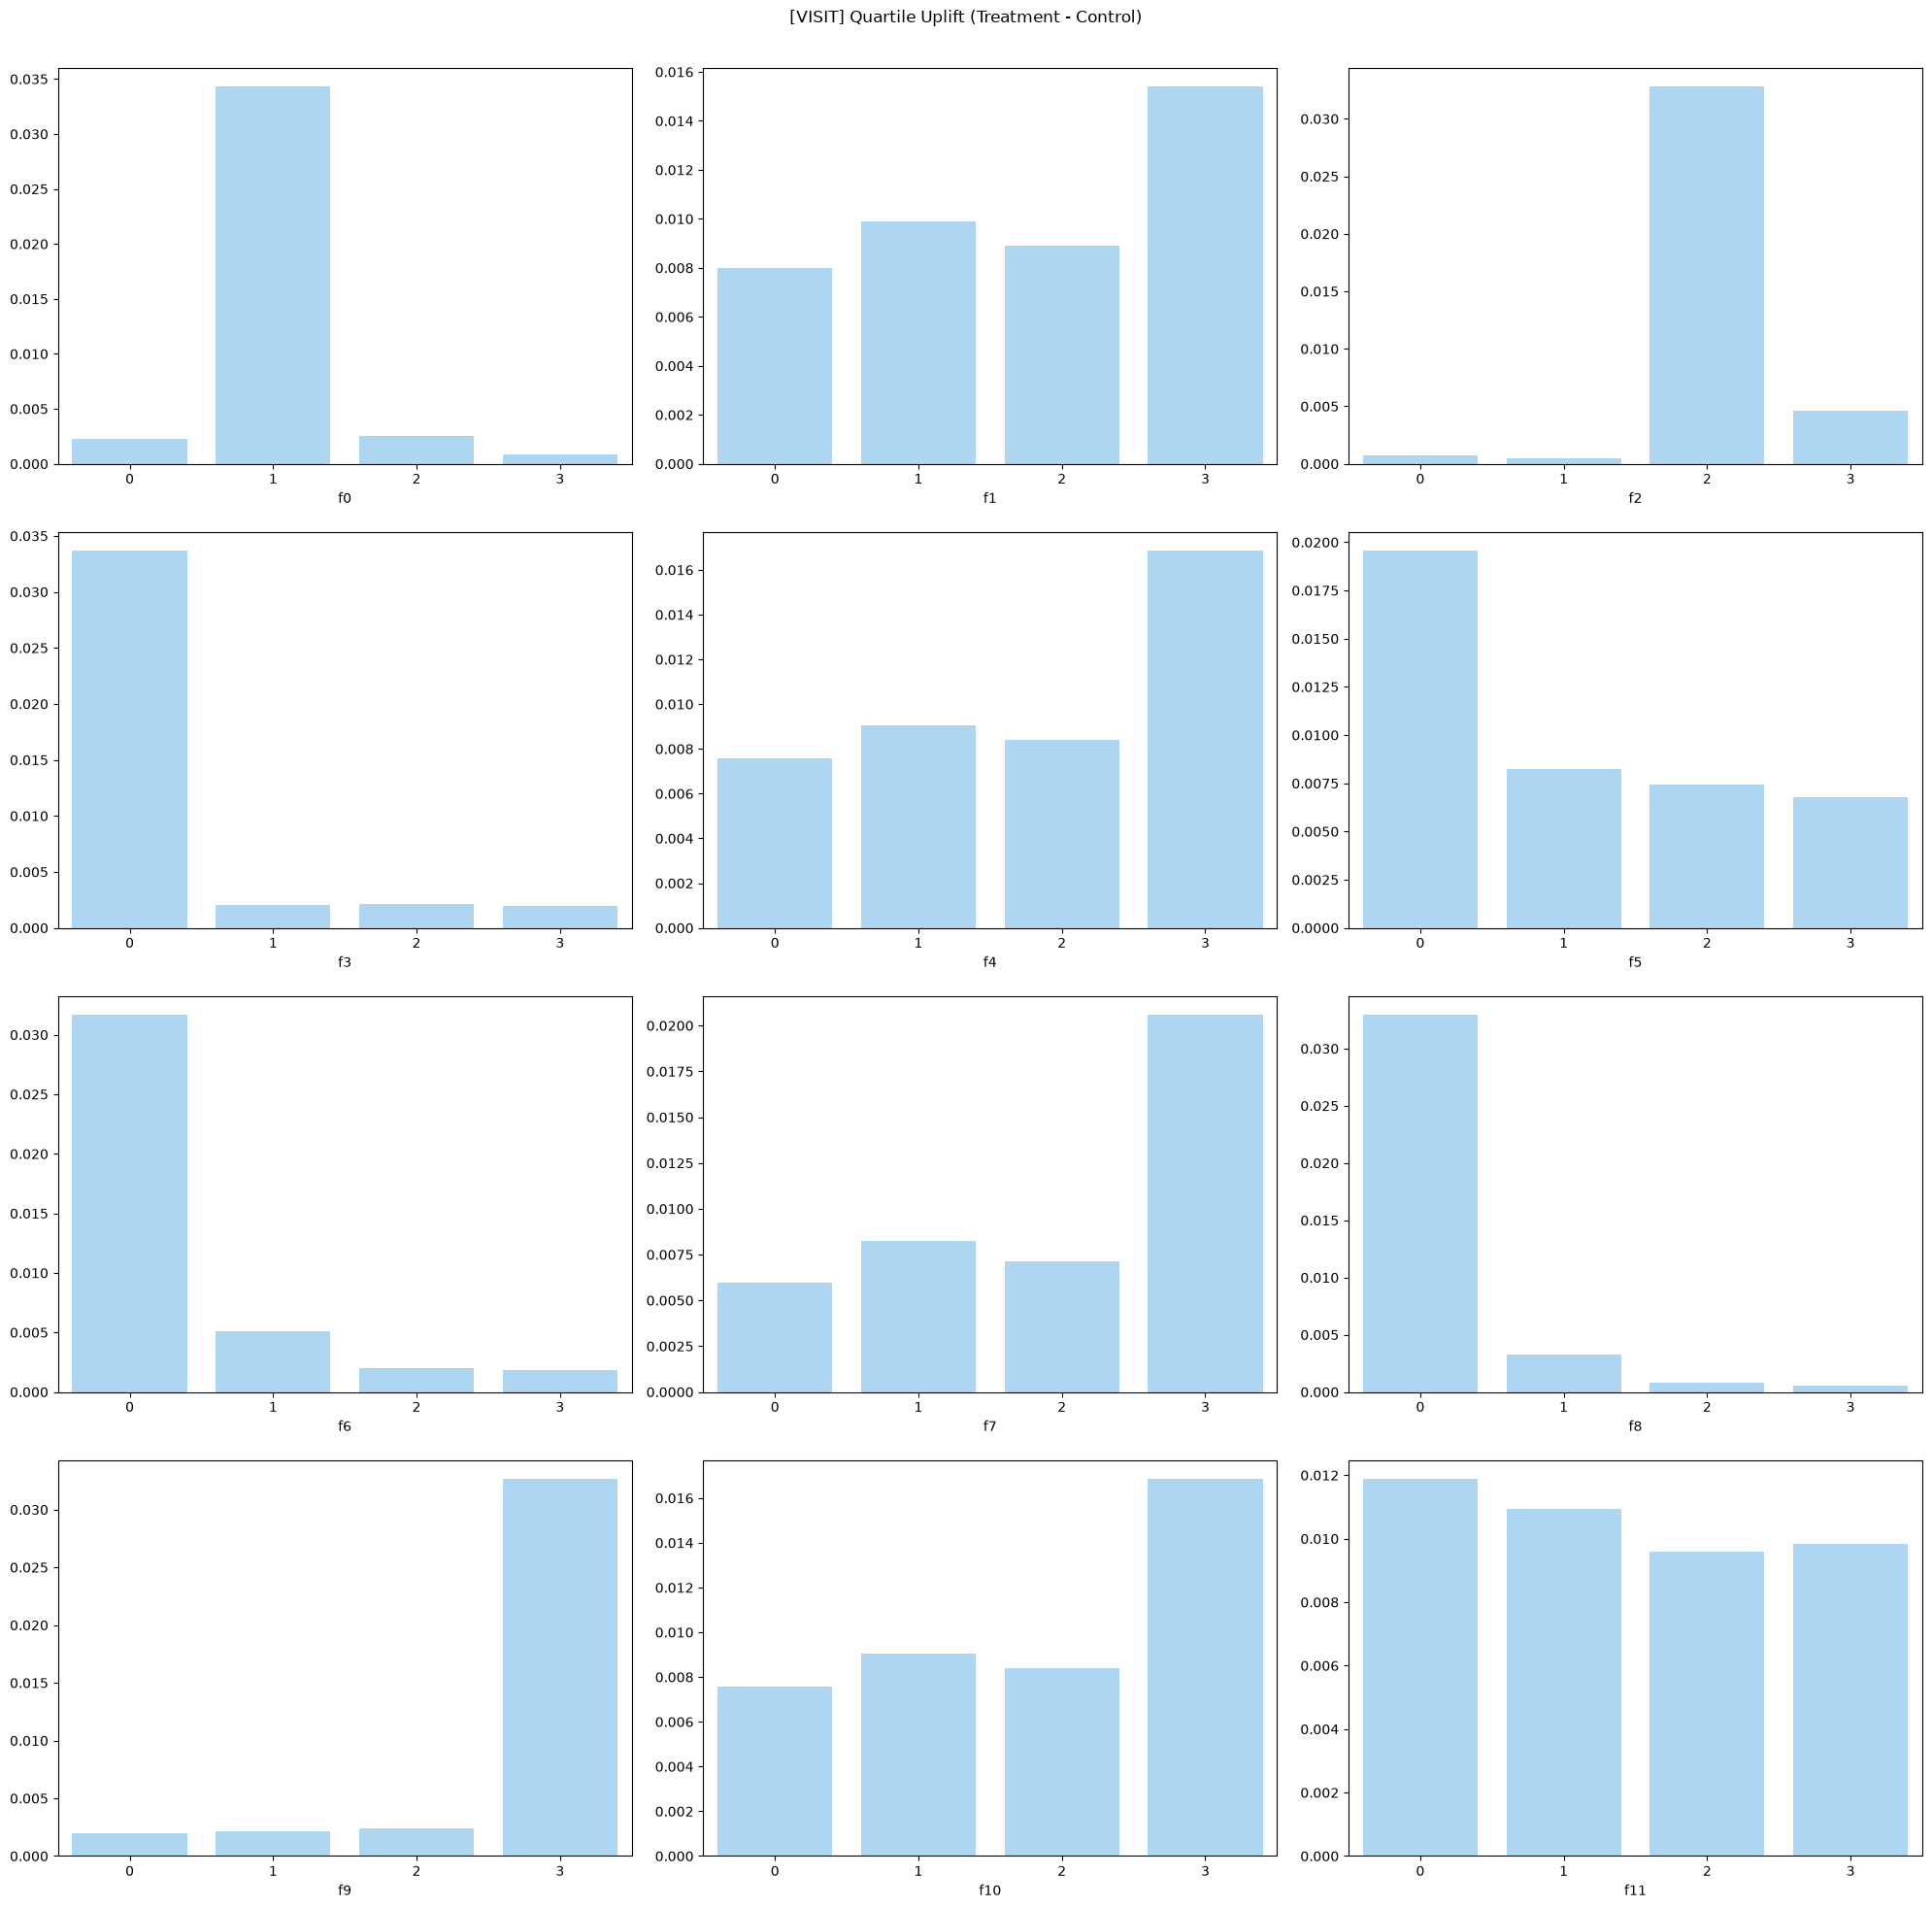

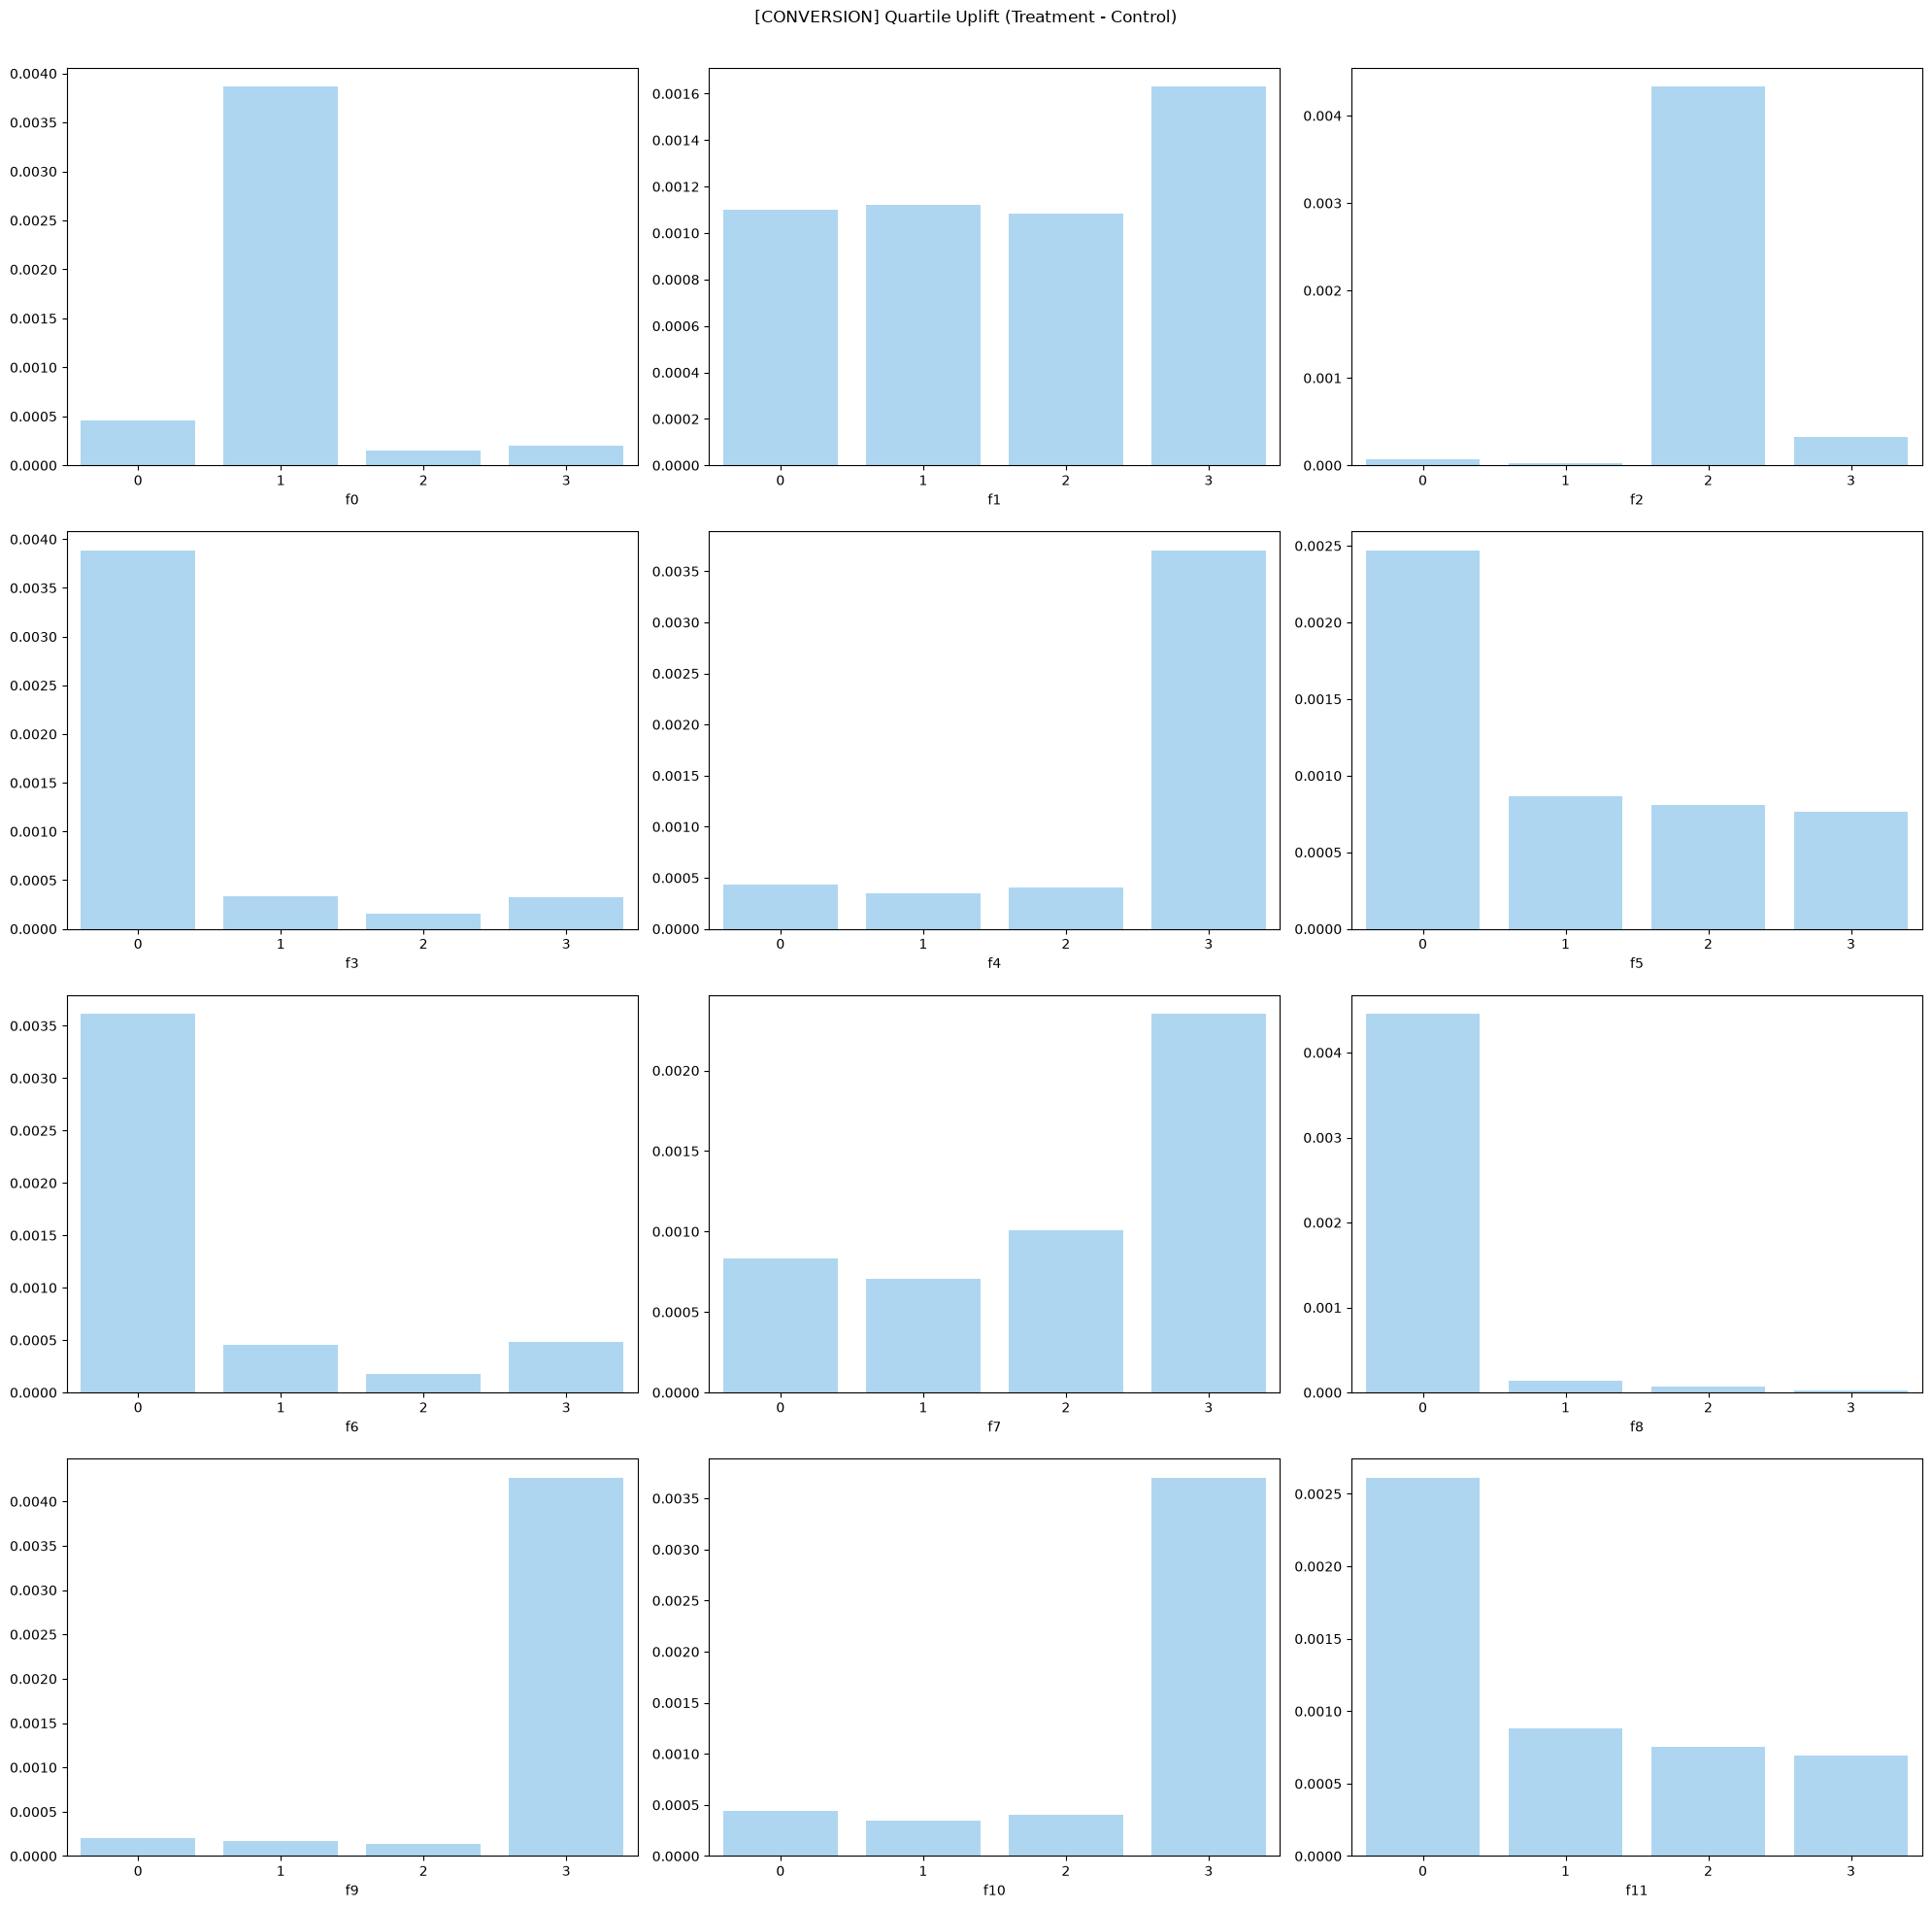

In [156]:
outcomes = [cfg.outcome_col, cfg.secondary_outcome_col]
uplift_matrices = {cfg.outcome_col: np.zeros((4, len(X.columns))),
                   cfg.secondary_outcome_col: np.zeros((4, len(X.columns)))}

for outcome in outcomes:
    for i, feature in enumerate(X.columns):
        for q in [1, 2, 3, 4]:
            uplift_matrices[outcome][q-1, i] = df_quartile[(df_quartile["treatment"]==1) & (df_quartile[feature]==q)][outcome].mean() - \
                                    df_quartile[(df_quartile["treatment"]==0) & (df_quartile[feature]==q)][outcome].mean()
    df_uplift= pd.DataFrame(uplift_matrices[outcome])
    
    fig, axes = plt.subplots(4, 3, figsize = (20,20))
    for i, column in enumerate(df_uplift.columns):
        plt.subplots_adjust(top = 0.85)
        ax = sns.barplot(data=df_uplift,
                        x=df_uplift.index,
                        y=df_uplift[i],
                        color="#A4D8FB",
                        ax = axes[(i) // 3, (i) % 3])
        ax.set_ylabel('')
        ax.set_xlabel(f'f{i}')
    fig.tight_layout(h_pad = 2)
    plt.suptitle(f'[{outcome.upper()}] Quartile Uplift (Treatment - Control)')
    fig.subplots_adjust(top = 0.95)

#### 6.1 Key Findings

**High Quartile Responders (f1, f4, f7, f9, f10):**  
Uplift is concentrated in Q4 for both visit and conversion outcomes, suggesting that 
users with higher values in these features are more responsive to treatment. Notably, 
these features are all left-skewed, meaning the majority of users fall in lower 
quartiles while the highly responsive segment represents a smaller, high-value group.

**Low Quartile Responders (f3, f5, f6, f8):**  
Uplift is concentrated in Q1, indicating that users with lower values in these 
right-skewed features are most treatment-responsive. The pattern is consistent 
across both visit and conversion outcomes.

**Single-Quartile Responders (f0, f2):**  
f0 shows peak uplift in Q2 while f2 shows peak uplift in Q3, with minimal uplift 
in remaining quartiles. Both features exhibit bimodal or multi-modal distributions, 
suggesting that the most treatment-responsive users occupy a transitional range 
between two distinct subpopulations. This pattern is consistent with the concept 
of "persuadables" in uplift modeling: users who are neither certain converters 
nor lost causes, but are movable by the intervention.

**f11 - Outcome-Dependent Behavior:**  
f11 exhibits consistent uplift across all quartiles for the visit outcome, suggesting 
treatment benefits users regardless of their f11 value. However, for conversion, 
f11 follows the low-quartile responder pattern, concentrating uplift in Q1. This 
discrepancy implies f11 may capture engagement quantity rather than purchase intent, 
making it more informative for conversion targeting than visit optimization.

#### 6.2 Implications for Modeling

The clear variation in uplift across quartiles confirms meaningful treatment effect 
heterogeneity in the Criteo dataset. This provides strong motivation for meta-learner 
approaches (T-Learner, X-Learner, and Causal Forest) which are 
designed to recover these subgroup-level effects. The persuadable segments identified 
here will serve as a qualitative benchmark for evaluating whether our models 
successfully recover heterogeneous treatment effects.

### 6.3 Next Steps
- Proceed to `02_preprocessing.ipynb` for feature transformation and data preparation
- Implement meta-learners in `03_modeling.ipynb`, using visit rate as the primary 
  outcome and conversion rate as secondary
- Revisit quartile patterns post-modeling to validate that learned CATE estimates 
  align with raw uplift observations